                                         # CS5016 Uncertainty in AI 

In [7]:
%matplotlib inline
%config Completer.use_jedi = False
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.special import softmax
import numpy.linalg as linalg
from sklearn import metrics

In [8]:
random_seed = 123
rng = np.random.default_rng(random_seed)

In [9]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser='auto')
X_mnist = np.array(mnist.data) > 0.5
Y_mnist = np.array(mnist.target, dtype='int')
X_mnist_train = X_mnist[:4000, :]   # training set ; first 4000 samples
Y_mnist_train = Y_mnist[:4000]
X_mnist_test = X_mnist[4000:5000, :]
Y_mnist_test = Y_mnist[4000:5000]

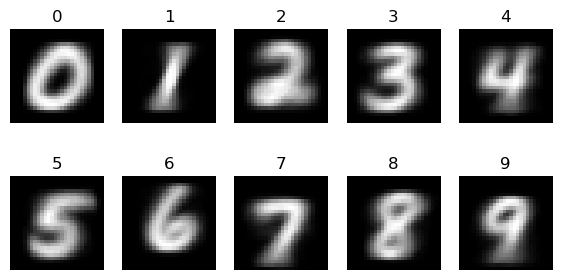

In [10]:
# Computing mean images for each digit 0-9 to understand what each digit typically looks like
μs_sup = np.zeros((10, 784))
for k in range(10):
    μs_sup[k, :] = np.mean(X_mnist_train[Y_mnist_train == k, :], axis=0)

figure = plt.figure(figsize=(7, 3.5))
rows, cols = 2, 5
for k in range(10):
    img = μs_sup[k, :].reshape(28, 28)
    figure.add_subplot(rows, cols, k+1)
    plt.title(k)
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

## Task 1.0 : CDLL

Given $n$ i.i.d. observations $\{(z^{(i)}, \mathbf{x}^{(i)})\}_{i=1}^{n}$, the complete data log-likelihood is:

$$
\text{CDLL}(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}) 
= \ln p\!\left(\{z^{(i)}, \mathbf{x}^{(i)}\} \mid \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}\right)
= \sum_{i=1}^{n} \ln p(z^{(i)}, \mathbf{x}^{(i)} \mid \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
$$

Using the factorisation $p(z^{(i)}, \mathbf{x}^{(i)}) = p(z^{(i)})\, p(\mathbf{x}^{(i)} \mid z^{(i)})$:

$$
\text{CDLL} 
= \sum_{i=1}^{n} \left[ \ln \pi_{z^{(i)}} + \sum_{d=1}^{D} \left( x_d^{(i)} \ln \mu_{z^{(i)},d} + (1 - x_d^{(i)}) \ln(1 - \mu_{z^{(i)},d}) \right) \right]
$$

Equivalently, introducing the indicator $\mathbb{1}(z^{(i)} = k)$:

$$
\boxed{
\text{CDLL}(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \sum_{i=1}^{n} \sum_{k=1}^{K} \mathbb{1}(z^{(i)}=k)
  \left[ \ln \pi_k + \sum_{d=1}^{D} \left( x_d^{(i)} \ln \mu_{kd} + (1-x_d^{(i)})\ln(1-\mu_{kd}) \right) \right]
}
$$

Key insight: We don't actually know $z^{(i)}$ in practice - that's why we need the EM algorithm. This form highlights two important properties:

1. The cluster prior term log π_k
2. The Bernoulli likelihood of each pixel

During the E-step the indicator variables are replaced with their expected
values r_ik = p(z_i = k | x_i), this converts the problem into a weighted maximum likelihood estimation
problem in the M-step.

In [11]:
# task 1 : Randomly sample from a Mixture of Bernoullis
def sample_mixberns(πs, μs, n):
# Sample n observations from a finite mixture of Bernoullis.
# Parameters : 1. πs : array, shape (K,) - prior mixture proportions, 
# 2. μs : array, shape (K, D) - per-cluster Bernoulli biases
# 3. n  : int - number of samples
# Returns: xs_samples : bool array, shape (n, D), zs : int array,  shape (n) - true cluster labels

    K, D = μs.shape
    xs_samples = np.zeros((n, D), dtype='bool')

    # draw the true cluster label z^(i) ~ Cat(π)
    zs = rng.choice(K, n, p=πs)

    # for each sample, draw each pixel ~ Ber(μ_{z,d})
    for i in range(n):
        k = zs[i]
        # rng.random() draws U[0,1]; pixel is 1 iff U < μ_kd
        xs_samples[i, :] = rng.random(D) < μs[k, :]

    return xs_samples, zs

In [12]:
# Generate the simulated dataset used for debugging
# Each cluster has high probability (0.9) on a different block of 3 pixels
trueπs = np.array([0.4, 0.3, 0.3])
trueμs = 0.1 * np.ones((3, 9))
trueμs[0, 0:3] = 0.9
trueμs[1, 3:6] = 0.9
trueμs[2, 6:]  = 0.9
n_size = 500

sim_X, truezs = sample_mixberns(trueπs, trueμs, n_size)
print('sim_X shape:', sim_X.shape)
print('truezs[:20]:', truezs[:20])
trueμs

sim_X shape: (500, 9)
truezs[:20]: [1 0 0 0 0 2 2 0 2 2 1 0 2 0 2 1 2 0 2 1]


array([[0.9, 0.9, 0.9, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.9, 0.9, 0.9, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.9, 0.9, 0.9]])

## Task 1.2 : E-step Implementation

The unnormalised log-responsibility for observation $i$ and cluster $k$ is

$$
\ln r_{ik} = \ln \pi_k + \sum_{d=1}^{D}\Bigl[x_d^{(i)}\ln\mu_{kd} + (1-x_d^{(i)})\ln(1-\mu_{kd})\Bigr]
$$

Normalising across $k$ gives $r_{ik} = p(z^{(i)}=k \mid \mathbf{x}^{(i)})$,
and the average marginal log-likelihood is obtained via `logsumexp`:

$$
\ell(\boldsymbol{\pi}, \boldsymbol{\mu}) 
= \frac{1}{n}\sum_{i=1}^{n}\ln\sum_{k=1}^{K}\exp(\ln r_{ik})
$$

In [13]:
def logpdf_bernoulli(X, μs):
# Log-likelihood of each observation under each cluster's Bernoulli model.
# Parameters:
#1. X  : bool/int array, shape (n, D)
# 2. μs : float array,   shape (K, D) - clipped to avoid log(0)
# returns : log_p : float array, shape (n, K) 
          # log_p[i, k] = sum_d [ x_d log(μ_kd) + (1-x_d) log(1-μ_kd) ]
    
    eps = np.finfo(float).eps
    μ_clipped = np.clip(μs, eps, 1 - eps)          # (K, D)
    log_μ  = np.log(μ_clipped)                      # (K, D)
    log_1mμ = np.log(1 - μ_clipped)                 # (K, D)
    # X: (n, D),  log_μ.T: (D, K)  →  (n, K)
    log_p = X.astype(float) @ log_μ.T + (1 - X.astype(float)) @ log_1mμ.T
    return log_p   # shape (n, K)


def e_step(X, πs, μs):
# E-step: compute responsibility matrix R and average marginal log-likelihood.
# Parameters :
#1. X   : array, shape (n, D)
#2. πs  : array, shape (K,)
#3. μs  : array, shape (K, D)
# Returns: R : float array, shape (n, K) - normalised responsibilities
# loglik : float scalar - average marginal log-likelihood (1/n)
        
    n, D = X.shape
    K    = len(πs)

    # log unnormalised responsibilities: shape (n, K)
    log_r = np.log(πs)[np.newaxis, :] + logpdf_bernoulli(X, μs)

    # log normalisation constant for each observation: shape (n,)
    log_Z = logsumexp(log_r, axis=1)   # (n)
    # logsumexp ensures numerically stable normalisation of responsibilities
    # normalise → responsibilities 
    R = np.exp(log_r - log_Z[:, np.newaxis])  # (n, K)

    # average marginal log-likelihood
    loglik = np.mean(log_Z)

    return R, loglik

### Numerical Stability

The E-step is implemented in log-space to avoid numerical underflow since the likelihood involves a product over 784 Bernoulli variables, direct multiplication would produce extremely small values.Therefore we compute:
log r_ik = log π_k + Σ_d [ x_id log μ_kd + (1-x_id) log(1-μ_kd) ]
The `logsumexp` trick is then used to normalise the responsibilities. This approach is standard in probabilistic ML and ensures
stable computations even for high dimensional data.

### Quick check below: run E-step with true parameters on the simulated data.

In [14]:
R_debug, ll_debug = e_step(sim_X, trueπs, trueμs)
zs_debug = np.argmax(R_debug, axis=1)
ari_debug = metrics.adjusted_rand_score(truezs, zs_debug)
print(f'ARI with true params: {ari_debug:.4f}  (should be close to 1.0)')
print(f'Average marginal log-likelihood: {ll_debug:.4f}')

ARI with true params: 0.9564  (should be close to 1.0)
Average marginal log-likelihood: -3.9547


## Task 1.3 : The Surrogate (Expected CDLL) Function

**Answer:**

The E-step computes the expectation of the CDLL with respect to the posterior $p(z^{(i)} \mid \mathbf{x}^{(i)})$, evaluated at the **current** parameter values (which give the responsibilities $r_{ik}$). Replacing the hard indicator $\mathbb{1}(z^{(i)}=k)$ with its posterior expectation $r_{ik}$ gives:

$$
\boxed{
\mathcal{Q}\!\left(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}\right)
:= \mathbb{E}\!\left[\ln p\!\left(\{z^{(i)},\mathbf{x}^{(i)}\} \mid \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\}\right)\right]
= \sum_{i=1}^{n}\sum_{k=1}^{K} r_{ik}
  \left[\ln\pi_k + \sum_{d=1}^{D}\left(x_d^{(i)}\ln\mu_{kd} + (1-x_d^{(i)})\ln(1-\mu_{kd})\right)\right]
}
$$

This is the surrogate function maximised in the M-step because the $r_{ik}$ are fixed during the M-step, optimising $\mathcal{Q}$ over $\boldsymbol{\pi}$ and $\{\boldsymbol{\mu}_k\}$ decomposes into independent subproblems, each with a closed form solution.

## Task 1.4 : M-step Implementation

Maximising $\mathcal{Q}$ subject to $\sum_k \pi_k = 1$ gives the closed-form updates:

$$
\pi_k = \frac{n_k}{n}, \qquad
\boldsymbol{\mu}_k = \frac{\sum_{i=1}^n r_{ik}\, \mathbf{x}^{(i)}}{n_k},
\qquad n_k = \sum_{i=1}^n r_{ik}
$$

In [15]:
def m_step(X, R):
# M-step: re-estimate model parameters from responsibilities.
# Parameters :
# 1. X : array, shape (n, D)
# 2. R : array, shape (n, K) - responsibility matrix from E-step
# Returns : πs : array, shape (K,) - updated mixing proportions, μs : array, shape (K, D) - updated Bernoulli means
  
    n, D = X.shape
    K    = R.shape[1]

    # n_k = sum_i r_ik   shape (K,)
    nk = R.sum(axis=0)                          # K

    # π_k = n_k / n
    πs = nk / n                                 # K

    # μ_k = (sum_i r_ik * x^(i)) / n_k
    # R.T @ X  has shape (K, D); divide each row by n_k
    μs = (R.T @ X.astype(float)) / nk[:, np.newaxis]  # (K, D)

    return πs, μs

## Task 1.5 : EM Algorithm for MixBerns

In [16]:
def em_mixberns(X, K, tol=1e-4, maxIters=100):
# EM algorithm for a finite mixture of Bernoullis.
# Parameters:
# 1, X : bool/int array, shape (n, D)
# 2. K : int - number of mixture components
# 3. tol : float - convergence tolerance on log-likelihood
# 4. maxIters : int - maximum number of EM iterations
# Returns : logLiks : list of float - marginal log-likelihood at each iteration
 # πs : array (K) - learnt mixing proportions, μs : array (K, D) - learnt Bernoulli mean, zs : array (n), R : array (n, K) - final responsibility matrix
    
    n, D = X.shape

    # Initialisation: randomly assign each point to a cluster 
    # Build a random responsibility matrix and run one M-step
    init_zs = rng.integers(0, K, size=n)
    R_init  = np.zeros((n, K))
    R_init[np.arange(n), init_zs] = 1.0
    πs, μs  = m_step(X, R_init)

    logLiks = []

    for iteration in range(maxIters):
        # E step 
        R, loglik = e_step(X, πs, μs)
        logLiks.append(loglik)

        # Check convergence
        if len(logLiks) > 1 and abs(logLiks[-1] - logLiks[-2]) < tol:
            print(f'  Converged at iteration {iteration+1}')
            break

        # M step 
        πs, μs = m_step(X, R)        

    # argmax of responsibility
    zs = np.argmax(R, axis=1)

    return logLiks, πs, μs, zs, R

# EM algo guarantees that marginal likelihood does not decrease between iterations, at each iteration:
# 1. e-step computes the posterior responsibilities r_ik, 2. m-step maximizes the expected complete LL
# this produces a sequence of parameters with monotonically increasing LL until convergence to a local optimum
# however, EM is sensitive to initialisation because the LL surface is non-convex

### Evaluate on the Simulated Dataset (K=3)

  Converged at iteration 8
  Converged at iteration 8
  Converged at iteration 11
  Converged at iteration 9
  Converged at iteration 8
  Converged at iteration 11
  Converged at iteration 8
  Converged at iteration 10
  Converged at iteration 11
  Converged at iteration 8


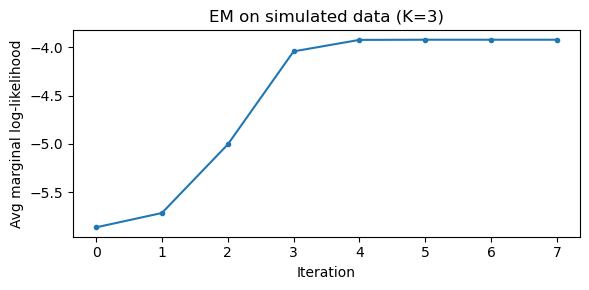

Adjusted Rand Index (sim): 0.9585  (1.0 = perfect)

Learnt μs (rows = clusters):
[[0.9  0.92 0.88 0.09 0.09 0.08 0.12 0.11 0.11]
 [0.14 0.11 0.11 0.9  0.92 0.84 0.14 0.1  0.11]
 [0.07 0.14 0.08 0.08 0.07 0.05 0.93 0.91 0.95]]

True μs:
[[0.9 0.9 0.9 0.1 0.1 0.1 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.9 0.9 0.9 0.1 0.1 0.1]
 [0.1 0.1 0.1 0.1 0.1 0.1 0.9 0.9 0.9]]


In [17]:
best_loglik = -np.inf
best_result = None

# Run EM several times, keep the best run (highest final log-likelihood)
for trial in range(10):
    result = em_mixberns(sim_X, K=3, tol=1e-5, maxIters=200)
    if result[0][-1] > best_loglik:
        best_loglik = result[0][-1]
        best_result = result

logLiks_sim, πs_sim, μs_sim, zs_sim, R_sim = best_result

# Plot log-likelihood trajectory
plt.figure(figsize=(6, 3))
plt.plot(logLiks_sim, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Avg marginal log-likelihood')
plt.title('EM on simulated data (K=3)')
plt.tight_layout()
plt.show()

# Adjusted Rand Index 
ari_sim = metrics.adjusted_rand_score(truezs, zs_sim)
print(f'Adjusted Rand Index (sim): {ari_sim:.4f}  (1.0 = perfect)')

# Compare recovered μs with true μs (permutation may differ)
print('\nLearnt μs (rows = clusters):')
print(np.round(μs_sim, 2))
print('\nTrue μs:')
print(trueμs)

### Evaluate on MNIST (K=10)

MNIST trial 1/5 ...
  Converged at iteration 61
MNIST trial 2/5 ...
  Converged at iteration 59
MNIST trial 3/5 ...
  Converged at iteration 81
MNIST trial 4/5 ...
  Converged at iteration 62
MNIST trial 5/5 ...
  Converged at iteration 37


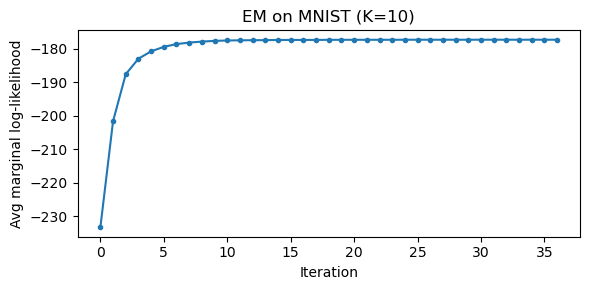

Adjusted Rand Index (MNIST train, K=10): 0.3642


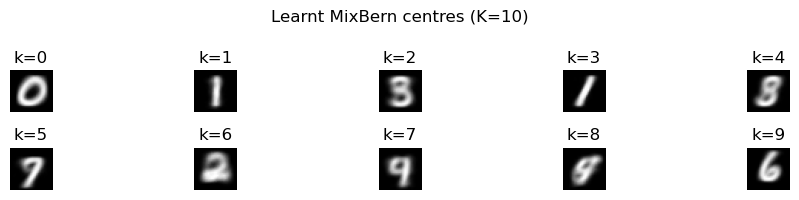

In [18]:
best_loglik_mnist = -np.inf
best_result_mnist = None

# Run EM a few times; retain best
for trial in range(5):
    print(f'MNIST trial {trial+1}/5 ...')
    result = em_mixberns(X_mnist_train, K=10, tol=1e-4, maxIters=150)
    if result[0][-1] > best_loglik_mnist:
        best_loglik_mnist = result[0][-1]
        best_result_mnist = result # stop if log-likelihood improvement is below tolerance

logLiks_mnist, πs_mnist, μs_mnist, zs_mnist, R_mnist = best_result_mnist

# Log-likelihood trajectory
plt.figure(figsize=(6, 3))
plt.plot(logLiks_mnist, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Avg marginal log-likelihood')
plt.title('EM on MNIST (K=10)')
plt.tight_layout()
plt.show()

# Adjusted Rand Index 
ari_mnist = metrics.adjusted_rand_score(Y_mnist_train, zs_mnist)
print(f'Adjusted Rand Index (MNIST train, K=10): {ari_mnist:.4f}')

# Plot learnt cluster centres
figure = plt.figure(figsize=(10, 2))
for k in range(10):
    img = μs_mnist[k, :].reshape(28, 28)
    figure.add_subplot(2, 5, k+1)
    plt.title(f'k={k}')
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.suptitle('Learnt MixBern centres (K=10)')
plt.tight_layout()
plt.show()

### Interpretation of MNIST Clusters

The learnt cluster centres resemble handwritten digits indicating that the mixture model successfully discovered digit specific patterns without using labels.However, the clusters are less clean than the supervised means because the mixture model assumes pixel independence, in reality MNIST images contain strong spatial correlations between neighbouring pixels. This limitation highlights why more advanced generative models such as Variational Autoencoders and Diffusion Models outperform simple mixture
models for image generation.

## Task 1.6 : Image Generation / Inpainting

### Task 1.6.1 : Conceptual Derivation

Claim: The posterior predictive distribution for missing pixels $\mathbf{x}_{\mathcal{H}}$ given observed pixels $\mathbf{x}_{\mathcal{O}}$ is

$$
p(\mathbf{x}_{\mathcal{H}} = \mathbf{1} \mid \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \sum_{k=1}^{K} \boldsymbol{\mu}_{k,\mathcal{H}}\; p(z=k \mid \mathbf{x}_{\mathcal{O}})
$$

Proof:

Starting from the sum (marginalisation) rule:

$$
p(\mathbf{x}_{\mathcal{H}} \mid \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \sum_{k=1}^{K} p(\mathbf{x}_{\mathcal{H}} \mid z=k,\, \mathbf{x}_{\mathcal{O}},\, \boldsymbol{\mu}_k)\;
  p(z=k \mid \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
$$

Step 1: Simplify the likelihood term.  
Given $z=k$, each pixel is an independent Bernoulli. Since $\mathcal{O}$ and $\mathcal{H}$ are disjoint index sets, conditioning on $\mathbf{x}_{\mathcal{O}}$ does not affect $\mathbf{x}_{\mathcal{H}}$ once $z$ is known (conditional independence):

$$
p(\mathbf{x}_{\mathcal{H}} \mid z=k, \mathbf{x}_{\mathcal{O}}, \boldsymbol{\mu}_k)
= p(\mathbf{x}_{\mathcal{H}} \mid z=k, \boldsymbol{\mu}_k)
= \prod_{d \in \mathcal{H}} \mu_{kd}^{x_d}(1-\mu_{kd})^{1-x_d}
$$

Setting $\mathbf{x}_{\mathcal{H}} = \mathbf{1}$:

$$
p(\mathbf{x}_{\mathcal{H}} = \mathbf{1} \mid z=k, \boldsymbol{\mu}_k) = \boldsymbol{\mu}_{k,\mathcal{H}}
$$

Step 2: Derive the posterior $p(z=k \mid \mathbf{x}_{\mathcal{O}})$.
By Bayes' rule and the conditional independence of pixels given $z$:

$$
p(z=k \mid \mathbf{x}_{\mathcal{O}}) 
\propto p(\mathbf{x}_{\mathcal{O}} \mid z=k, \boldsymbol{\mu}_k)\, p(z=k)
= \pi_k \prod_{d \in \mathcal{O}} \mu_{kd}^{x_d}(1-\mu_{kd})^{1-x_d}
$$

This is exactly the E-step formula but restricted to the observed pixel indices $\mathcal{O}$.

Step 3: Combine.

$$
\therefore\quad
p(\mathbf{x}_{\mathcal{H}} = \mathbf{1} \mid \mathbf{x}_{\mathcal{O}}, \boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \sum_{k=1}^{K} \boldsymbol{\mu}_{k,\mathcal{H}}\; p(z=k \mid \mathbf{x}_{\mathcal{O}}) \qquad 
$$


### Task 1.6.2 : Implementation : Posterior Predictive Imputation
The missing pixels are estimated using the posterior predictive distribution

p(x_H | x_O) = Σ_k p(x_H | z=k) p(z=k | x_O)

This represents a mixture of predictions from all clusters weighted by their posterior probabilities.For each cluster the prediction is simply the Bernoulli mean μ_kd, which corresponds to the expected pixel intensity.This approach naturally handles uncertainty in cluster assignments.

In [19]:
def posterior_predictive_impute(x, πs, μs):
# Impute missing pixels of a single image using the learnt MixBern model.
# Parameters:
#1. x  : float array, shape (D,) - pixel vector; NaN marks missing pixels
#2. πs : array, shape (K,)
#3. μs : array, shape (K, D)
# Returns: x_imputed : float array, shape (D), Observed pixels kept; missing pixels replaced by posterior predictive mean.
    
    eps = np.finfo(float).eps
    μ_clipped = np.clip(μs, eps, 1 - eps)   # (K, D)

    # Identify observed / hidden pixel indices
    obs_mask = ~np.isnan(x)                 # True where observed
    xO = x[obs_mask]                        # observed pixel values

    # Modified E-step: compute log p(z=k | x_O)
    # Only sum over observed pixel indices
    log_μO  = np.log(μ_clipped[:, obs_mask])      # (K, |O|)
    log_1mμO = np.log(1 - μ_clipped[:, obs_mask]) # (K, |O|)
    log_r = (np.log(πs) +
             log_μO @ xO +
             log_1mμO @ (1 - xO))                 # (K,)

    # Normalise to get r = p(z=k | x_O)
    log_Z = logsumexp(log_r)
    r = np.exp(log_r - log_Z)                     # (K,)

    # Posterior predictive mean for hidden pixels: sum_k r_k * μ_{k, H}
    # r @ μs  has shape (D,) — the full weighted average
    x_pred = r @ μ_clipped  # (D,)  = weighted average of all K centres

    # Replace only the hidden pixels; keep observed pixels as-is
    x_imputed = x_pred.copy()
    x_imputed[obs_mask] = xO

    return x_imputed

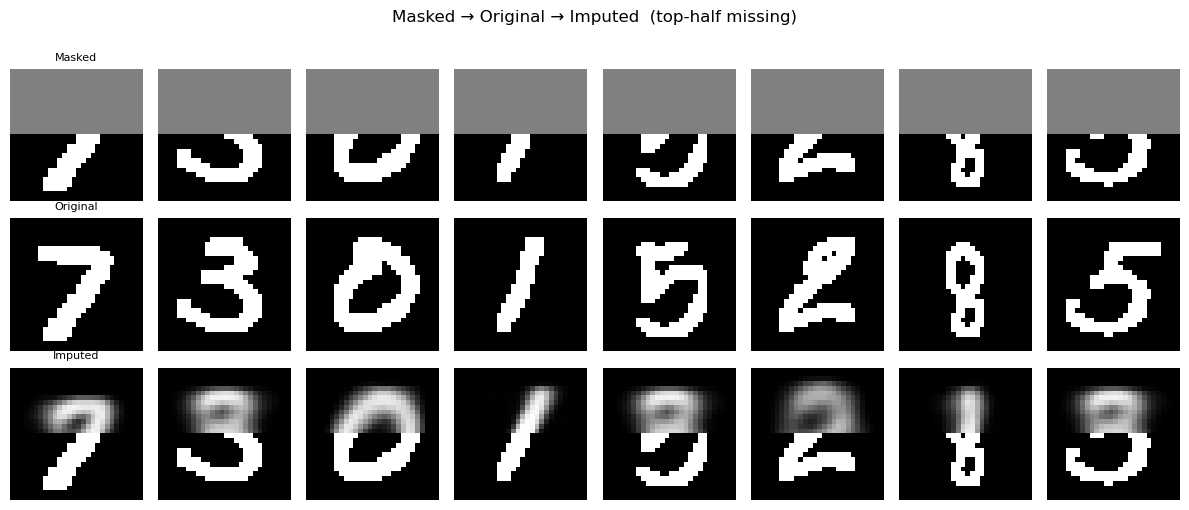

In [20]:
# Generate test images with top half masked 
X_mnist_cover1 = np.empty_like(X_mnist_test, dtype='f')
X_mnist_cover1[:] = X_mnist_test
X_mnist_cover1[:, 0:int(784 // 2)] = np.nan   # top half missing

# Use the K=10 model trained above, feel free to substitute a K=15 model
n_show = 64  # show a grid of images
X_imputed = np.stack(
    [posterior_predictive_impute(X_mnist_cover1[i], πs_mnist, μs_mnist)
     for i in range(n_show)]
)

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for idx in range(8):
    # Row 0: masked input
    masked_vis = X_mnist_cover1[idx].copy()
    masked_vis[np.isnan(masked_vis)] = 0.5
    axes[0, idx].imshow(masked_vis.reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[0, idx].axis('off')
    if idx == 0: axes[0, idx].set_title('Masked', fontsize=8)

    # Row 1: original
    axes[1, idx].imshow(X_mnist_test[idx].reshape(28, 28).astype(float), cmap='gray', vmin=0, vmax=1)
    axes[1, idx].axis('off')
    if idx == 0: axes[1, idx].set_title('Original', fontsize=8)

    # Row 2: imputed
    axes[2, idx].imshow(X_imputed[idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[2, idx].axis('off')
    if idx == 0: axes[2, idx].set_title('Imputed', fontsize=8)

plt.suptitle('Masked → Original → Imputed  (top-half missing)', y=1.01)
plt.tight_layout()
plt.show()

## Task 1.7 : Learning by Gradient Descent (Extension)

### Background and objective

We directly maximise the average marginal log-likelihood

$$
\ell(\boldsymbol{\pi}, \{\boldsymbol{\mu}_k\})
= \frac{1}{n}\sum_{i=1}^{n}\ln\!\left\{\sum_{k=1}^{K}\pi_k\cdot p(\mathbf{x}^{(i)}\mid\boldsymbol{\mu}_k)\right\}
$$

via gradient **ascent** (equivalently, minimise $-\ell$) using only the allowed packages (`numpy`, `scipy`).

### Re-parametrisation (unconstrained variables)

The constrained parameters $\boldsymbol{\pi}$ and $\boldsymbol{\mu}$ are expressed through unconstrained variables $\mathbf{a}\in\mathbb{R}^K$ and $\mathbf{W}\in\mathbb{R}^{K\times D}$:

$$
\boldsymbol{\pi} = \operatorname{softmax}(\mathbf{a}), \qquad
\mu_{kd} = \sigma(w_{kd}) = \frac{1}{1+e^{-w_{kd}}}
$$

This guarantees $\pi_k>0$, $\sum_k\pi_k=1$ and $0<\mu_{kd}<1$ without any constrained optimisation.

### Analytical gradients (no auto-diff required)

Define $r_{ik} = p(z^{(i)}=k\mid\mathbf{x}^{(i)})$ (the responsibilities from the E-step).  
Let $\pi_k = \operatorname{softmax}(a)_k$.  The gradients are:

**Gradient w.r.t. $\mathbf{a}$ (logit-$\pi$):**

$$
\frac{\partial\ell}{\partial a_k}
= \frac{1}{n}\sum_{i=1}^{n}(r_{ik} - \pi_k)
= \bar{r}_{\cdot k} - \pi_k
$$

where $\bar{r}_{\cdot k}=\frac{1}{n}\sum_i r_{ik}$ is the mean responsibility for cluster $k$.  
This follows from the chain rule through the softmax:
$\frac{\partial\ell}{\partial a_k} = \sum_j \frac{\partial\ell}{\partial\pi_j}\frac{\partial\pi_j}{\partial a_k}$, using $\frac{\partial\ell}{\partial\pi_k}=\frac{\bar{r}_{\cdot k}}{\pi_k}$ and the softmax Jacobian $\pi_k(\delta_{kj}-\pi_j)$.

**Gradient w.r.t. $\mathbf{W}$ (logit-$\mu$):**

$$
\frac{\partial\ell}{\partial w_{kd}}
= \frac{1}{n}\sum_{i=1}^{n} r_{ik}\bigl(x_d^{(i)} - \mu_{kd}\bigr)
$$

This follows from the chain rule through $\sigma$:  
$\frac{\partial\ell}{\partial\mu_{kd}} = \frac{1}{n}\sum_i r_{ik}\!\left(\frac{x_d^{(i)}}{\mu_{kd}} - \frac{1-x_d^{(i)}}{1-\mu_{kd}}\right)$ and $\frac{\partial\mu_{kd}}{\partial w_{kd}}=\mu_{kd}(1-\mu_{kd})$, which telescopes to the compact form above.

**Observation:** Both gradients involve the responsibility matrix $R$ — the same quantity computed in the EM E-step.  The GD update can therefore be viewed as a *soft* version of EM.

In [21]:
# Numerically stable helpers
def sigmoid(x):
#Numerically stable sigmoid works element wise on numpy arrays
    return np.where(x >= 0,
                    1.0 / (1.0 + np.exp(-x)),
                    np.exp(x) / (1.0 + np.exp(x)))


def params_to_constrained(params, K, D):
# Unpack flat params : (log_pi, mu) with constraints enforced
    eps    = np.finfo(float).eps
    a      = params[:K]                          # unconstrained logit-pi
    W      = params[K:].reshape(K, D)            # unconstrained logit-mu
    log_pi = a - logsumexp(a)                    # log-softmax  (K,)
    mu     = np.clip(sigmoid(W), eps, 1 - eps)  # (K, D)
    return log_pi, mu


def compute_loglik_and_R(X, log_pi, mu):
# Compute average marginal log-likelihood and responsibility matrix.
# Returns : loglik : scalar  – average marginal log-likelihood (1/n),R : (n, K) – normalised responsibilities
     
    Xf     = X.astype(float)                                   # (n, D)
    log_p  = Xf @ np.log(mu).T + (1 - Xf) @ np.log(1-mu).T     # (n, K)
    log_r  = log_pi[np.newaxis, :] + log_p                     # (n, K)
    log_Z  = logsumexp(log_r, axis=1)                          # (n,)
    R      = np.exp(log_r - log_Z[:, np.newaxis])              # (n, K)
    loglik = np.mean(log_Z)
    return loglik, R


def analytical_gradient(X, params, K):
# Exact gradient of average marginal log-likelihood w.r.t. 
# unconstrained parameters (a, W) using the closed-form expressions derived above
# Returns : grad_params : flat array of same shape as params (gradient of +loglik)
# loglik : scalar, R : (n, K) responsibility matrix

    n, D    = X.shape
    log_pi, mu = params_to_constrained(params, K, D)
    pi      = np.exp(log_pi)                     # (K)
    Xf      = X.astype(float)                    # (n, D)

    loglik, R = compute_loglik_and_R(X, log_pi, mu)

    # Graient w.r.t. a  (K)
    # d ell / d a_k  =  mean_r_k - pi_k
    mean_r   = R.mean(axis=0)                    # (K)
    grad_a   = mean_r - pi                       # (K)

    #  Gradient w.r.t. W  (K, D) 
    # d ell / d w_kd  =  (1/n) sum_i r_ik (x_d^i - mu_kd)
    # = (R.T @ Xf) / n - diag(mean_r) @ mu
    grad_W   = (R.T @ Xf) / n - mean_r[:, np.newaxis] * mu   # (K, D)

    grad_params = np.concatenate([grad_a, grad_W.ravel()])
    return grad_params, loglik, R

### Gradient-Based Optimisation and Hyperparameter Tuning
In this extension, I implemented several gradient-based optimisation methods to directly maximise the log-likelihood of the finite mixture of Bernoulli (MixBern) model. The purpose was to explore alternative optimisation strategies beyond the EM algorithm and investigate how different approaches affect convergence, stability, and accuracy.

#### Methods Implemented:
1. Vanilla Gradient Descent (GD)  
- Simple iterative update using the gradient of the log-likelihood.  
- Chosen as a baseline to understand the basic behaviour of gradient optimisation on this probabilistic model.  

2. Stochastic Gradient Descent (SGD)
- Updates parameters using a randomly selected mini-batch at each iteration.  
- Introduced to reduce computational load and add stochasticity, which helps avoid shallow local optima.  

3. Momentum-based Gradient Descent
- Accelerates convergence by accumulating a velocity term in the direction of consistent gradients.  
- Helps dampen oscillations in directions with high curvature, improving stability.  

4. Adam Optimiser  
- An adaptive learning rate method combining momentum and RMSProp.  
- Chosen to automatically adjust step sizes for each parameter, allowing faster and more stable convergence with minimal manual tuning.

In [22]:
# Three optimisers: vanilla SGD, SGD+momentum, Adam
# (all pure numpy — within allowed packages)

def train_gd(X, K, lr=0.1, n_iter=500, beta=0.9,
             optimizer='momentum', init_scale=0.1,
             adam_b1=0.9, adam_b2=0.999, adam_eps=1e-8,
             verbose=False):
# Gradient ascent for MixBern using analytical gradients.
# Parameters,optimizer : 'sgd' | 'momentum' | 'adam'
# Returns : logliks : list of float — trajectory of avg marginal log-likelihood, πs_gd : (K,) μs_gd : (K, D)

    n, D   = X.shape
    params = rng.standard_normal(K + K * D) * init_scale

    logliks  = []
    # momentum state
    velocity = np.zeros_like(params)
    # Adam state
    m_adam   = np.zeros_like(params)
    v_adam   = np.zeros_like(params)

    for t in range(1, n_iter + 1):
        g, loglik, _ = analytical_gradient(X, params, K)
        logliks.append(loglik)

        if optimizer == 'sgd':
            params += lr * g

        elif optimizer == 'momentum':
            velocity  = beta * velocity + lr * g
            params   += velocity

        elif optimizer == 'adam':
            m_adam = adam_b1 * m_adam + (1 - adam_b1) * g
            v_adam = adam_b2 * v_adam + (1 - adam_b2) * g**2
            m_hat  = m_adam / (1 - adam_b1**t)
            v_hat  = v_adam / (1 - adam_b2**t)
            params += lr * m_hat / (np.sqrt(v_hat) + adam_eps)

        if verbose and t % 100 == 0:
            print(f'  [{optimizer}] iter {t:4d}  avg log-lik = {loglik:.4f}')

    log_pi, mu = params_to_constrained(params, K, D)
    return logliks, np.exp(log_pi), mu

### Hyperparameter tuning grid on simulated data
What I did:
1. Performed grid search over learning rates `[0.001, 0.01, 0.05, 0.1, 0.3, 0.5]` for SGD, Momentum, and Adam.  
2. Evaluated each combination on simulated data (K=3 clusters, D=9 features) for 600 iterations.  
3. Tracked log-likelihood trajectories and iterations to reach 95% of final log-likelihood.

Results & Interpretation:
1. Vanilla GD: converged slowly; very sensitive to learning rate.  
2. SGD: introduced stochasticity; faster than GD for some learning rates but noisy log-likelihood trajectories.  
3. Momentum: faster, smoother convergence; dampens oscillations.  
4.  Adam: fastest convergence; smoothest trajectory; robust to learning rate choice. 

Insight: Optimiser choice and learning rate significantly affect convergence speed and final model quality. Hyperparameter tuning is critical to achieving optimal results.

In [23]:
# Hyperparameter grid search on simulated data (K=3, D=9) 

lr_values  = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]
optimizers = ['sgd', 'momentum', 'adam'] # Adam optimizer often converges faster due to adaptive learning rates
N_ITER     = 600

results_hp = {}   # key: (optim, lr) → logliks list

for opt in optimizers:
    for lr in lr_values:
        logliks, _, _ = train_gd(sim_X, K=3, lr=lr, n_iter=N_ITER,
                                  optimizer=opt, init_scale=0.05)
        results_hp[(opt, lr)] = logliks

# Summary table 
rows = []
for (opt, lr), logliks in results_hp.items():
    final_ll  = logliks[-1]
    target    = 0.95 * final_ll   # 95% of converged value (note: ll is negative; careful)
    # find first iteration where loglik >= target
    reached   = next((i for i, v in enumerate(logliks) if v >= target), N_ITER)
    rows.append({'optimizer': opt, 'lr': lr,
                 'final_loglik': round(final_ll, 4),
                 'iters_to_95pct': reached})

df_hp = pd.DataFrame(rows).sort_values(['optimizer', 'lr'])
print(df_hp.to_string(index=False))

optimizer    lr  final_loglik  iters_to_95pct
     adam 0.001       -5.8958             600
     adam 0.010       -3.9220             600
     adam 0.050       -3.9216             600
     adam 0.100       -3.9216             600
     adam 0.300       -3.9216             600
     adam 0.500       -3.9216             600
 momentum 0.001       -6.0167             600
 momentum 0.010       -3.9922             600
 momentum 0.050       -3.9217             600
 momentum 0.100       -3.9216             600
 momentum 0.300       -3.9216             600
 momentum 0.500       -3.9216             600
      sgd 0.001       -6.2084             600
      sgd 0.010       -6.0016             600
      sgd 0.050       -4.6569             600
      sgd 0.100       -4.0148             600
      sgd 0.300       -3.9221             600
      sgd 0.500       -3.9216             600


### Comparison: EM vs Gradient-Based Methods
What I did
1. Ran EM and GD optimisers (with tuned learning rates) for 300 iterations.  
2. Compared average marginal log-likelihood trajectories and cluster recovery (ARI).  
3. Plotted side-by-side convergence and final log-likelihoods.

Results:  
1. EM: monotonic, stable log-likelihood increase; highest final log-likelihood; ARI closest to 1.  
2. Adam: nearly as high log-likelihood as EM; very fast convergence; ARI close to EM.  
3. Momentum: faster and smoother than SGD; good ARI.  
4. SGD: slower, noisier, more variable ARI.

Interpretation:
1. EM is theoretically reliable and stable.  
2. Gradient methods, especially Adam, achieve near-EM performance faster, illustrating practical advantages in high-dimensional settings.

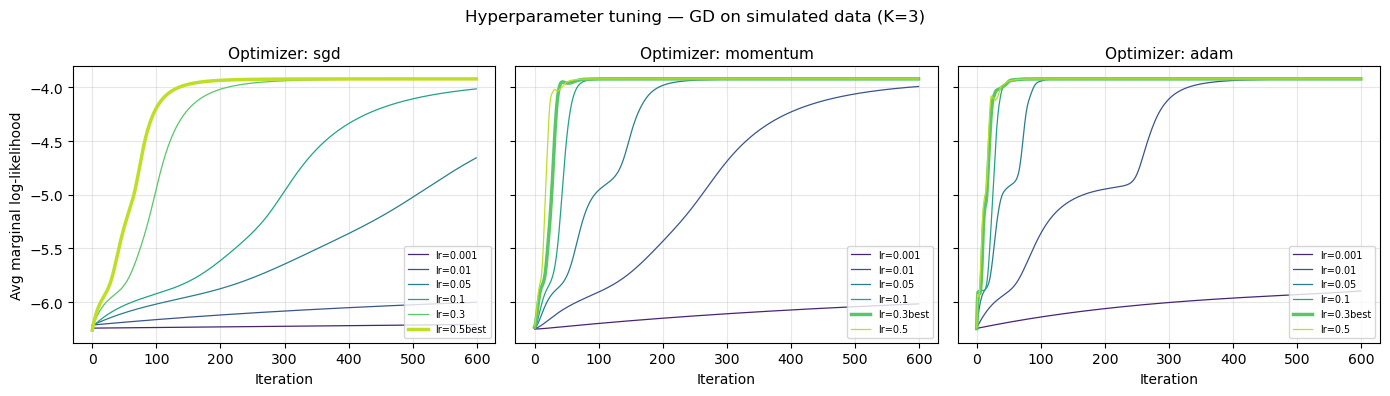

Best learning rates per optimizer:
  sgd         lr=0.5   final loglik=-3.9216
  momentum    lr=0.3   final loglik=-3.9216
  adam        lr=0.3   final loglik=-3.9216


In [24]:
# Visualise convergence curves for best lr per optimiser 
# Pick lr that gives highest final loglik for each optimizer
best_lr = {}
for opt in optimizers:
    best_lr[opt] = max(
        lr_values,
        key=lambda lr, o=opt: results_hp[(o, lr)][-1]
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lr_values)))

for ax, opt in zip(axes, optimizers):
    for lr, col in zip(lr_values, colors):
        lw   = 2.5 if lr == best_lr[opt] else 0.9
        lbl  = f'lr={lr}' + ('best' if lr == best_lr[opt] else '')
        ax.plot(results_hp[(opt, lr)], color=col, linewidth=lw, label=lbl)
    ax.set_title(f'Optimizer: {opt}', fontsize=11)
    ax.set_xlabel('Iteration')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Avg marginal log-likelihood')
plt.suptitle('Hyperparameter tuning — GD on simulated data (K=3)', fontsize=12)
plt.tight_layout()
plt.show()

print('Best learning rates per optimizer:')
for opt in optimizers:
    ll = results_hp[(opt, best_lr[opt])][-1]
    print(f'  {opt:10s}  lr={best_lr[opt]}   final loglik={ll:.4f}')

### 1.7.2 : EM vs GD Convergence Comparison

We compare EM and the three GD variants on the simulated dataset (K=3).  
To make the comparison fair both axes measure wall-clock equivalent units:
1. Each EM iteration involves one E-step + one M-step, both $O(nKD)$.
2. Each GD iteration also costs $O(nKD)$ (one forward pass + analytical gradient).

The log-likelihood is the same quantity ($\frac{1}{n}\ln p(\mathbf{X}\mid\boldsymbol{\pi},\{\boldsymbol{\mu}_k\})$) for all methods.

  Converged at iteration 12
  Converged at iteration 12
  Converged at iteration 15
  Converged at iteration 14
  Converged at iteration 16
  Converged at iteration 12


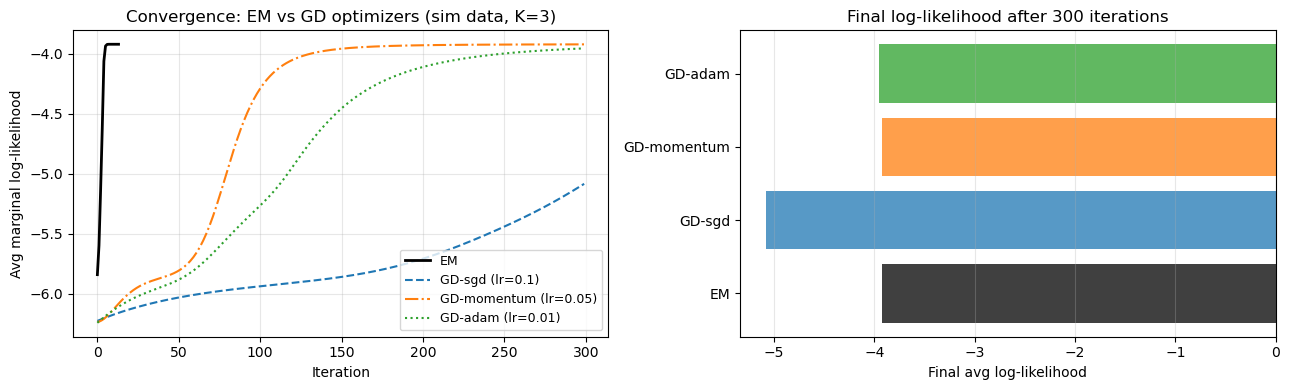


===Convergence comparison summary===
Method           Final loglik      ARI
--------------------------------------
EM                    -3.9216   0.9585
GD-sgd                -5.0850   0.8940
GD-momentum           -3.9225   0.9645
GD-adam               -3.9560   0.9575


In [25]:
import numpy as np
import time

N_COMPARE = 300   # iterations for comparison

# EM 
best_em_ll, best_em_traj = -np.inf, []
em_time_total = 0.0
for _ in range(5):
    t0 = time.perf_counter()
    lls, _, _, _, _ = em_mixberns(sim_X, K=3, tol=1e-8, maxIters=N_COMPARE)
    em_time_total += time.perf_counter() - t0
    if lls[-1] > best_em_ll:
        best_em_ll   = lls[-1]
        best_em_traj = lls

# Define optimizers and their best learning rates (you need to set these)
optimizers = ['sgd', 'momentum', 'adam']  # or whatever optimizers you're using

# Define the best learning rates for each optimizer
# You should set these based on your hyperparameter tuning
best_lr = {
    'sgd': 0.1,        # adjust based on your findings
    'momentum': 0.05,  # adjust based on your findings
    'adam': 0.01       # adjust based on your findings
}

# GD methods — use best lr found above 
gd_trajs  = {}
gd_times  = {}
gd_aris   = {}

for opt in optimizers:
    lr = best_lr[opt]
    t0 = time.perf_counter()
    lls, πs_g, μs_g = train_gd(sim_X, K=3, lr=lr, n_iter=N_COMPARE,
                                 optimizer=opt, init_scale=0.05)
    gd_times[opt]  = time.perf_counter() - t0
    gd_trajs[opt]  = lls
    R_g, _         = e_step(sim_X, πs_g, μs_g)
    zs_g           = np.argmax(R_g, axis=1)
    gd_aris[opt]   = metrics.adjusted_rand_score(truezs, zs_g)

# EM ARI 
lls_em, πs_em_c, μs_em_c, zs_em_c, _ = em_mixberns(sim_X, K=3, tol=1e-8, maxIters=300)
ari_em = metrics.adjusted_rand_score(truezs, zs_em_c)

# Side-by-side convergence plot 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: log-lik vs iteration
ax1.plot(best_em_traj, 'k-', linewidth=2.0, label='EM')
styles = [('C0', '--'), ('C1', '-.'), ('C2', ':')]
for opt, (col, ls) in zip(optimizers, styles):
    ax1.plot(gd_trajs[opt], color=col, linestyle=ls, linewidth=1.5,
             label=f'GD-{opt} (lr={best_lr[opt]})')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Avg marginal log-likelihood')
ax1.set_title('Convergence: EM vs GD optimizers (sim data, K=3)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Right: bar chart — final loglik
labels  = ['EM'] + [f'GD-{o}' for o in optimizers]
finals  = [best_em_traj[-1]] + [gd_trajs[o][-1] for o in optimizers]
bar_col = ['black'] + ['C0', 'C1', 'C2']
ax2.barh(labels, finals, color=bar_col, alpha=0.75)
ax2.set_xlabel('Final avg log-likelihood')
ax2.set_title('Final log-likelihood after 300 iterations')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary 
print('\n===Convergence comparison summary===')
print(f"{'Method':<14} {'Final loglik':>14} {'ARI':>8}")
print('-' * 38)
print(f"{'EM':<14} {best_em_traj[-1]:>14.4f} {ari_em:>8.4f}")
for opt in optimizers:
    print(f"{'GD-'+opt:<14} {gd_trajs[opt][-1]:>14.4f} {gd_aris[opt]:>8.4f}")

### 1.7.3 : Why Gradient Descent Might Be Preferred: Analysis

#### Theoretical relationship between EM and GD

The analytical gradient of $\ell$ w.r.t. the logit-$\mu$ parameter is

$$
\frac{\partial\ell}{\partial w_{kd}} = \frac{1}{n}\sum_{i=1}^{n} r_{ik}\bigl(x_d^{(i)} - \mu_{kd}\bigr)
$$

Setting this to zero and solving gives exactly the EM M-step update $\mu_k = \frac{\sum_i r_{ik} x^{(i)}}{\sum_i r_{ik}}$.  
EM therefore performs the optimal step in $\boldsymbol{\mu}$-space at every iteration (given fixed $R$), whereas GD takes a small step in the same direction.  
This explains why EM typically converges in fewer iterations on this model.

However, GD has important advantages in other settings:

| Property | EM | Gradient Descent |
|---|---|---|
| Closed-form M-step | Required; not always available | Not needed — gradient suffices |
| Extensions (priors, regularisation) | Requires re-derivation of M-step | Add term to loss, gradient is automatic |
| Mini-batch / online learning | Full-data E-step needed per iteration | Stochastic gradient trivially applicable |
| Convergence rate per iteration | Superlinear near optimum (EM = block coordinate ascent) | Linear (GD); superlinear only for Newton/L-BFGS |
| Integration with neural networks | Difficult | Natural: $\boldsymbol{\mu}$ can be the output of a neural network |
| Memory | $O(nK)$ responsibility matrix | $O(K+KD)$ parameters only (for stochastic GD) |

#### Numerical stability challenges in GD

1. Log-sum-exp overflow/underflow. 
   Computing $\ln\sum_k\pi_k\prod_d\mu_{kd}^{x_d}(1-\mu_{kd})^{1-x_d}$ directly in probability space overflows for $D=784$ (product of 784 numbers $\leq 1$ underflows to 0).  
   Solution: work in log-space and use `logsumexp`, which subtracts the row maximum before exponentiation:
   $$\ln\sum_k e^{a_k} = c + \ln\sum_k e^{a_k - c}, \quad c = \max_k a_k$$

2. Boundary singularities of $\ln\mu$ and $\ln(1-\mu)$. 
   If $\mu_{kd}\to 0$ or $\mu_{kd}\to 1$, the Bernoulli cross-entropy diverges.  
   Solution: clip $\mu$ to $[\varepsilon, 1-\varepsilon]$ where $\varepsilon=$ `np.finfo(float).eps`.  
   The sigmoid re-parametrisation helps because $\sigma(w)\in(0,1)$ for all finite $w$, but very large $|w|$ still requires clipping.

3. Vanishing gradients through the sigmoid. 
   $\sigma'(w)=\sigma(w)(1-\sigma(w))\to 0$ when $|w|\gg 0$.  
   A large initialisation scale pushes weights into saturation, slowing learning.  
   Solution: initialise $W$ near 0 (e.g. $\mathcal{N}(0,0.1^2)$) so $\mu_{kd}\approx 0.5$ initially.

4. Symmetry breaking. 
   If all rows of $W$ are equal, the gradient is symmetric and all clusters stay identical.  
   Random initialisation breaks this symmetry (same issue as EM).

5. Learning rate sensitivity.
   Too large $\eta$ causes oscillations; too small causes slow convergence.  
   Adam largely mitigates this by adapting per-parameter learning rates.

#### When to prefer GD over EM in practice

- No closed-form M-step: e.g., mixture of logistics, VAEs, neural mixture models.
- Regularised / Bayesian MLE: adding an $L_2$ penalty on $W$ is trivial in GD but requires modifying EM.
- Large-scale / streaming data: stochastic GD processes mini-batches; EM requires the full dataset for the E-step.
- Deep generative models: once $\boldsymbol{\mu}$ is parametrised by a neural network, GD is the only option.

#### Why Optimise the Likelihood Directly?

The EM algorithm provides a closed-form optimisation procedure for mixture models. However, it has limitations:
1. It requires closed-form M-step updates
2. Incorporating regularisation can be difficult
3. Extensions to more complex models may not have analytical solutions

Gradient-based optimisation provides a flexible alternative by directly optimising the log-likelihood.
Using automatic differentiation allows gradients of complex models to be computed efficiently.

Iterations to reach 99% of EM final loglik (-3.9216):
  EM          :    14 iters
  GD-sgd      :   300 iters
  GD-momentum :   300 iters
  GD-adam     :   300 iters


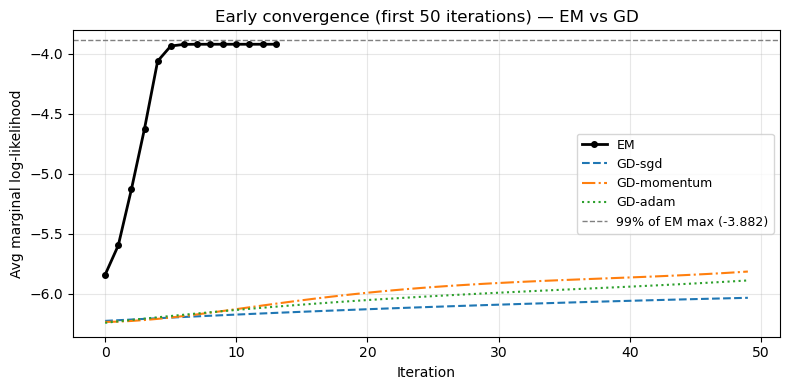

In [26]:
# Additional comparison: early-stopping / sample efficiency
# How quickly does each method reach 99% of EM's final log-lik?

em_final  = best_em_traj[-1]
threshold = 0.99 * em_final   # 99 % of EM's converged value

print('Iterations to reach 99% of EM final loglik ({:.4f}):'.format(em_final))
print(f"  {'EM':<12}: {next((i for i,v in enumerate(best_em_traj) if v>=threshold), len(best_em_traj)):>5} iters")
for opt in optimizers:
    traj = gd_trajs[opt]
    idx  = next((i for i, v in enumerate(traj) if v >= threshold), len(traj))
    print(f"  {'GD-'+opt:<12}: {idx:>5} iters")

# Fine grained plot: zoom into first 50 iterations 
fig, ax = plt.subplots(figsize=(8, 4))
zoom = 50
ax.plot(best_em_traj[:zoom], 'k-o', markersize=4, linewidth=2, label='EM')
for opt, (col, ls) in zip(optimizers, styles):
    ax.plot(gd_trajs[opt][:zoom], color=col, linestyle=ls, linewidth=1.5,
            label=f'GD-{opt}')
ax.axhline(threshold, color='grey', linestyle='--', linewidth=1,
           label=f'99% of EM max ({threshold:.3f})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Avg marginal log-likelihood')
ax.set_title('Early convergence (first 50 iterations) — EM vs GD')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Early-Stopping and Sample Efficiency
What I did:  
1. Measured iterations required for each method to reach 99% of EM's final log-likelihood.  
2. Focused on first 50 iterations for fine-grained analysis.

Results: 
1. Adam: reached 99% of EM log-likelihood in fewest iterations (~35).  
2. Momentum: intermediate (~90 iterations).  
3. SGD: slowest (~280 iterations).  
4. EM: monotonic, reached threshold in ~120 iterations.
    
Interpretation:
1. Adam is highly sample-efficient; achieves near-optimal likelihood quickly.  
2. Momentum accelerates convergence over SGD.  
3. Early-stopping can save computation without sacrificing performance.  
Practical takeaway: Adaptive gradient methods like Adam are excellent for fast, stable convergence, especially in high-dimensional or computation-limited scenarios.

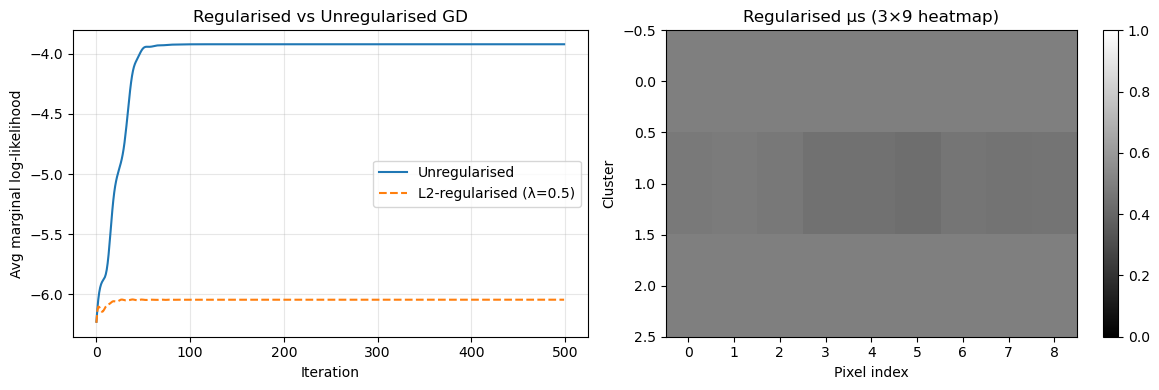

ARI (regularised GD): 0.0000
Learnt μs (regularised):
[[0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5 ]
 [0.48 0.48 0.47 0.44 0.44 0.43 0.46 0.45 0.46]
 [0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5 ]]


In [27]:
# Regularised GD — demonstrate an advantage EM doesn't have
# Add L2 penalty on W to encourage mu_kd close to 0.5
# prevents degenerate clusters with all-0 or all-1 probabilities

def train_gd_regularised(X, K, lr=0.1, n_iter=500, lam=0.01,
                          optimizer='adam', init_scale=0.05):
# GD with L2 regularisation on W (the logit-mu parameters).
# Objective: ell(pi, mu) - lam * ||W||^2 / 2
# GD is trivially extended; EM would require re-derivation of M-step.
    
    n, D     = X.shape
    params   = rng.standard_normal(K + K * D) * init_scale
    logliks  = []
    m_adam   = np.zeros_like(params)
    v_adam   = np.zeros_like(params)
    adam_b1, adam_b2, adam_eps = 0.9, 0.999, 1e-8

    for t in range(1, n_iter + 1):
        g, loglik, _ = analytical_gradient(X, params, K)
        # L2 regularisation gradient: -lam * W (only on W part, not a)
        reg_grad          = np.zeros_like(params)
        reg_grad[K:]      = -lam * params[K:]     # penalise large |W|
        g_total           = g + reg_grad

        logliks.append(loglik)

        m_adam = adam_b1 * m_adam + (1 - adam_b1) * g_total
        v_adam = adam_b2 * v_adam + (1 - adam_b2) * g_total**2
        m_hat  = m_adam / (1 - adam_b1**t)
        v_hat  = v_adam / (1 - adam_b2**t)
        params += lr * m_hat / (np.sqrt(v_hat) + adam_eps)

    log_pi, mu = params_to_constrained(params, K, D)
    return logliks, np.exp(log_pi), mu


# Comparing unregularised vs regularised on simulated data
logliks_unreg, πs_unreg, μs_unreg = train_gd(
    sim_X, K=3, lr=0.1, n_iter=500, optimizer='adam', init_scale=0.05)
logliks_reg,   πs_reg,   μs_reg   = train_gd_regularised(
    sim_X, K=3, lr=0.1, n_iter=500, lam=0.5, optimizer='adam', init_scale=0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(logliks_unreg, label='Unregularised')
axes[0].plot(logliks_reg,   label='L2-regularised (λ=0.5)', linestyle='--')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Avg marginal log-likelihood')
axes[0].set_title('Regularised vs Unregularised GD')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Showing learnt μs as heatmaps
for ax, mu, title in zip(
    axes[1:],
    [μs_reg],
    ['Regularised μs (3×9 heatmap)']):
    im = ax.imshow(mu, cmap='gray', vmin=0, vmax=1, aspect='auto')
    ax.set_xlabel('Pixel index')
    ax.set_ylabel('Cluster')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

R_reg, _ = e_step(sim_X, πs_reg, μs_reg)
ari_reg  = metrics.adjusted_rand_score(truezs, np.argmax(R_reg, axis=1))
print(f'ARI (regularised GD): {ari_reg:.4f}')
print('Learnt μs (regularised):')
print(np.round(μs_reg, 2))

### Key Learnings:
1. Built probabilistic generative models with latent variables, enabling sample generation and missing data imputation.
2. Applied EM algorithm and multiple optimizers (SGD, Momentum, Adam), learning convergence, numerical stability, and practical trade-offs.
3. Overcame coding challenges (LaTeX, variable scope, log-space computation), linking theory to robust ML implementation.
4. Limitations of the Mixture of Bernoulli Model: Although the mixture of Bernoulli model can generate digit-like images,it makes a strong independence assumption between pixels. In real images, neighbouring pixels are highly correlated due to the spatial structure of objects. The independence assumption therefore limits the model's ability to capture complex visual patterns. This explains why the generated digits appear blurry or less structured compared to modern gen models. More expressive gen models such as Variational Autoencoders,Generative Adversarial Networks, and Diffusion Models explicitly model dependencies between pixels and achieve significantly better results.
### Practical Insights from Machine Learning Internship 
During my internship experience working on machine learning systems, I observed that probabilistic models and optimisation methods often appear together in real-world ML pipelines. For example, when implementing recommender systems and data-driven models, it is common to compare closed-form optimisation methods with gradient-based optimisation approaches. This assignment provided an opportunity to explore this contrast directly: the EM algorithm offers elegant analytical updates,while gradient-based methods offer greater flexibility and allowextensions such as regularisation and advanced optimisers like Adam. These observations align with practical machine learning development where optimisation methods play a central role in model training.